In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix, roc_curve, auc,
    ConfusionMatrixDisplay, make_scorer
)

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

%matplotlib inline
plt.style.use('seaborn-v0_8')

In [2]:
df = pd.read_csv("/home/muthu/Desktop/Classifier_PI/CTD_dataset/merged_PIs_nonPIs_CTD_feat_.csv")

X = df.drop(columns=["label"])
y = df["label"]

X_train_cv, X_test, y_train_cv, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

neg, pos = (y_train_cv == 0).sum(), (y_train_cv == 1).sum()
scale_pos_weight = neg / pos if pos > 0 else 1
print(f"Negative:Positive ratio → {scale_pos_weight:.2f}")
print(f"Training set: {X_train_cv.shape[0]:,} | Test set: {X_test.shape[0]:,}")

Negative:Positive ratio → 2.16
Training set: 18,101 | Test set: 4,526


In [3]:
models = {
    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'mcc': make_scorer(matthews_corrcoef)
}

In [4]:
cv_rows = []
cv_per_fold_scores = {metric: {name: [] for name in models} for metric in scoring}

for name, clf in models.items():
    print(f"Cross-validating {name}...")
    results = cross_validate(clf, X_train_cv, y_train_cv, cv=cv, scoring=scoring, n_jobs=1)
    
    entry = {"Model": name}
    for metric in scoring:
        scores = results[f'test_{metric}']
        entry[metric] = f"{scores.mean():.4f} ± {scores.std():.4f}"
        cv_per_fold_scores[metric][name] = scores.tolist()
    
    cv_rows.append(entry)

cv_df = pd.DataFrame(cv_rows).set_index("Model")
cv_df

Cross-validating Random Forest...
Cross-validating XGBoost...
Cross-validating LightGBM...


,accuracy,precision,recall,f1,roc_auc,mcc
Model,,,,,,
Random Forest,0.9017 ± 0.0054,0.9194 ± 0.0092,0.7558 ± 0.0169,0.8295 ± 0.0107,0.9524 ± 0.0031,0.7687 ± 0.0130
XGBoost,0.9148 ± 0.0036,0.8904 ± 0.0065,0.8333 ± 0.0126,0.8609 ± 0.0067,0.9626 ± 0.0017,0.8005 ± 0.0088
LightGBM,0.9001 ± 0.0035,0.8151 ± 0.0103,0.8853 ± 0.0098,0.8487 ± 0.0045,0.9625 ± 0.0023,0.7759 ± 0.0069


In [5]:
test_rows = []
trained_models = {}
y_probas = {}
y_preds = {}

for name, clf in models.items():
    print(f"Training {name} on full training data...")
    clf.fit(X_train_cv, y_train_cv)
    trained_models[name] = clf
    
    pred = clf.predict(X_test)
    proba = clf.predict_proba(X_test)[:, 1]
    
    y_preds[name] = pred
    y_probas[name] = proba
    
    test_rows.append({
        "Model": name,
        "accuracy": round(accuracy_score(y_test, pred), 4),
        "precision": round(precision_score(y_test, pred, zero_division=0), 4),
        "recall": round(recall_score(y_test, pred), 4),
        "f1": round(f1_score(y_test, pred), 4),
        "roc_auc": round(roc_auc_score(y_test, proba), 4),
        "mcc": round(matthews_corrcoef(y_test, pred), 4)
    })

test_df = pd.DataFrame(test_rows).set_index("Model")
test_df

Training Random Forest on full training data...
Training XGBoost on full training data...
Training LightGBM on full training data...


,accuracy,precision,recall,f1,roc_auc,mcc
Model,,,,,,
Random Forest,0.9090,0.9181,0.7823,0.8448,0.9586,0.786
XGBoost,0.9176,0.8829,0.8528,0.8676,0.9677,0.808
LightGBM,0.9041,0.8116,0.9079,0.8570,0.9690,0.788


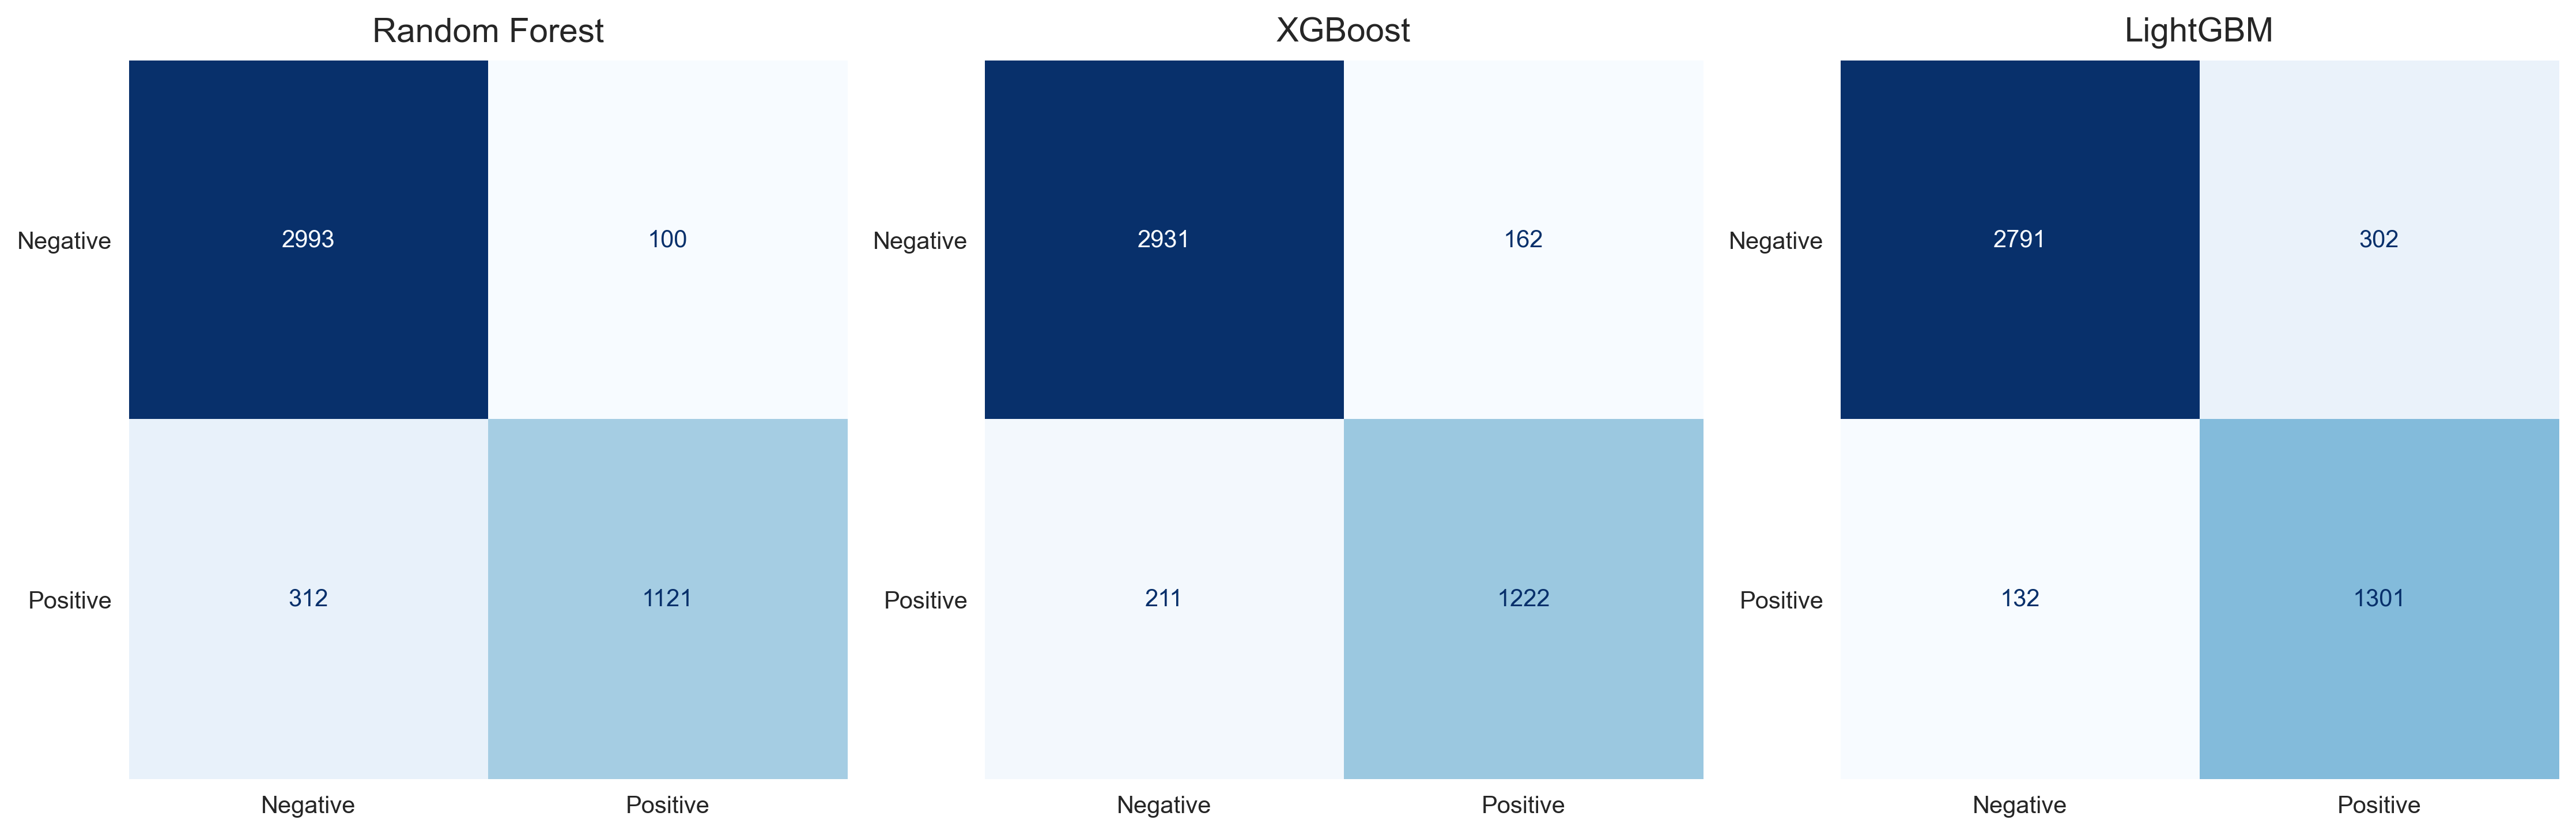

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300)

for ax, (name, pred) in zip(axes, y_preds.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, pred),
        display_labels=["Negative", "Positive"]
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    disp.im_.set_interpolation("nearest")
    ax.set_title(name, fontsize=14, pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)
    ax.tick_params(axis="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig("confusion_matrices.pdf", dpi=300, bbox_inches="tight")
plt.show()


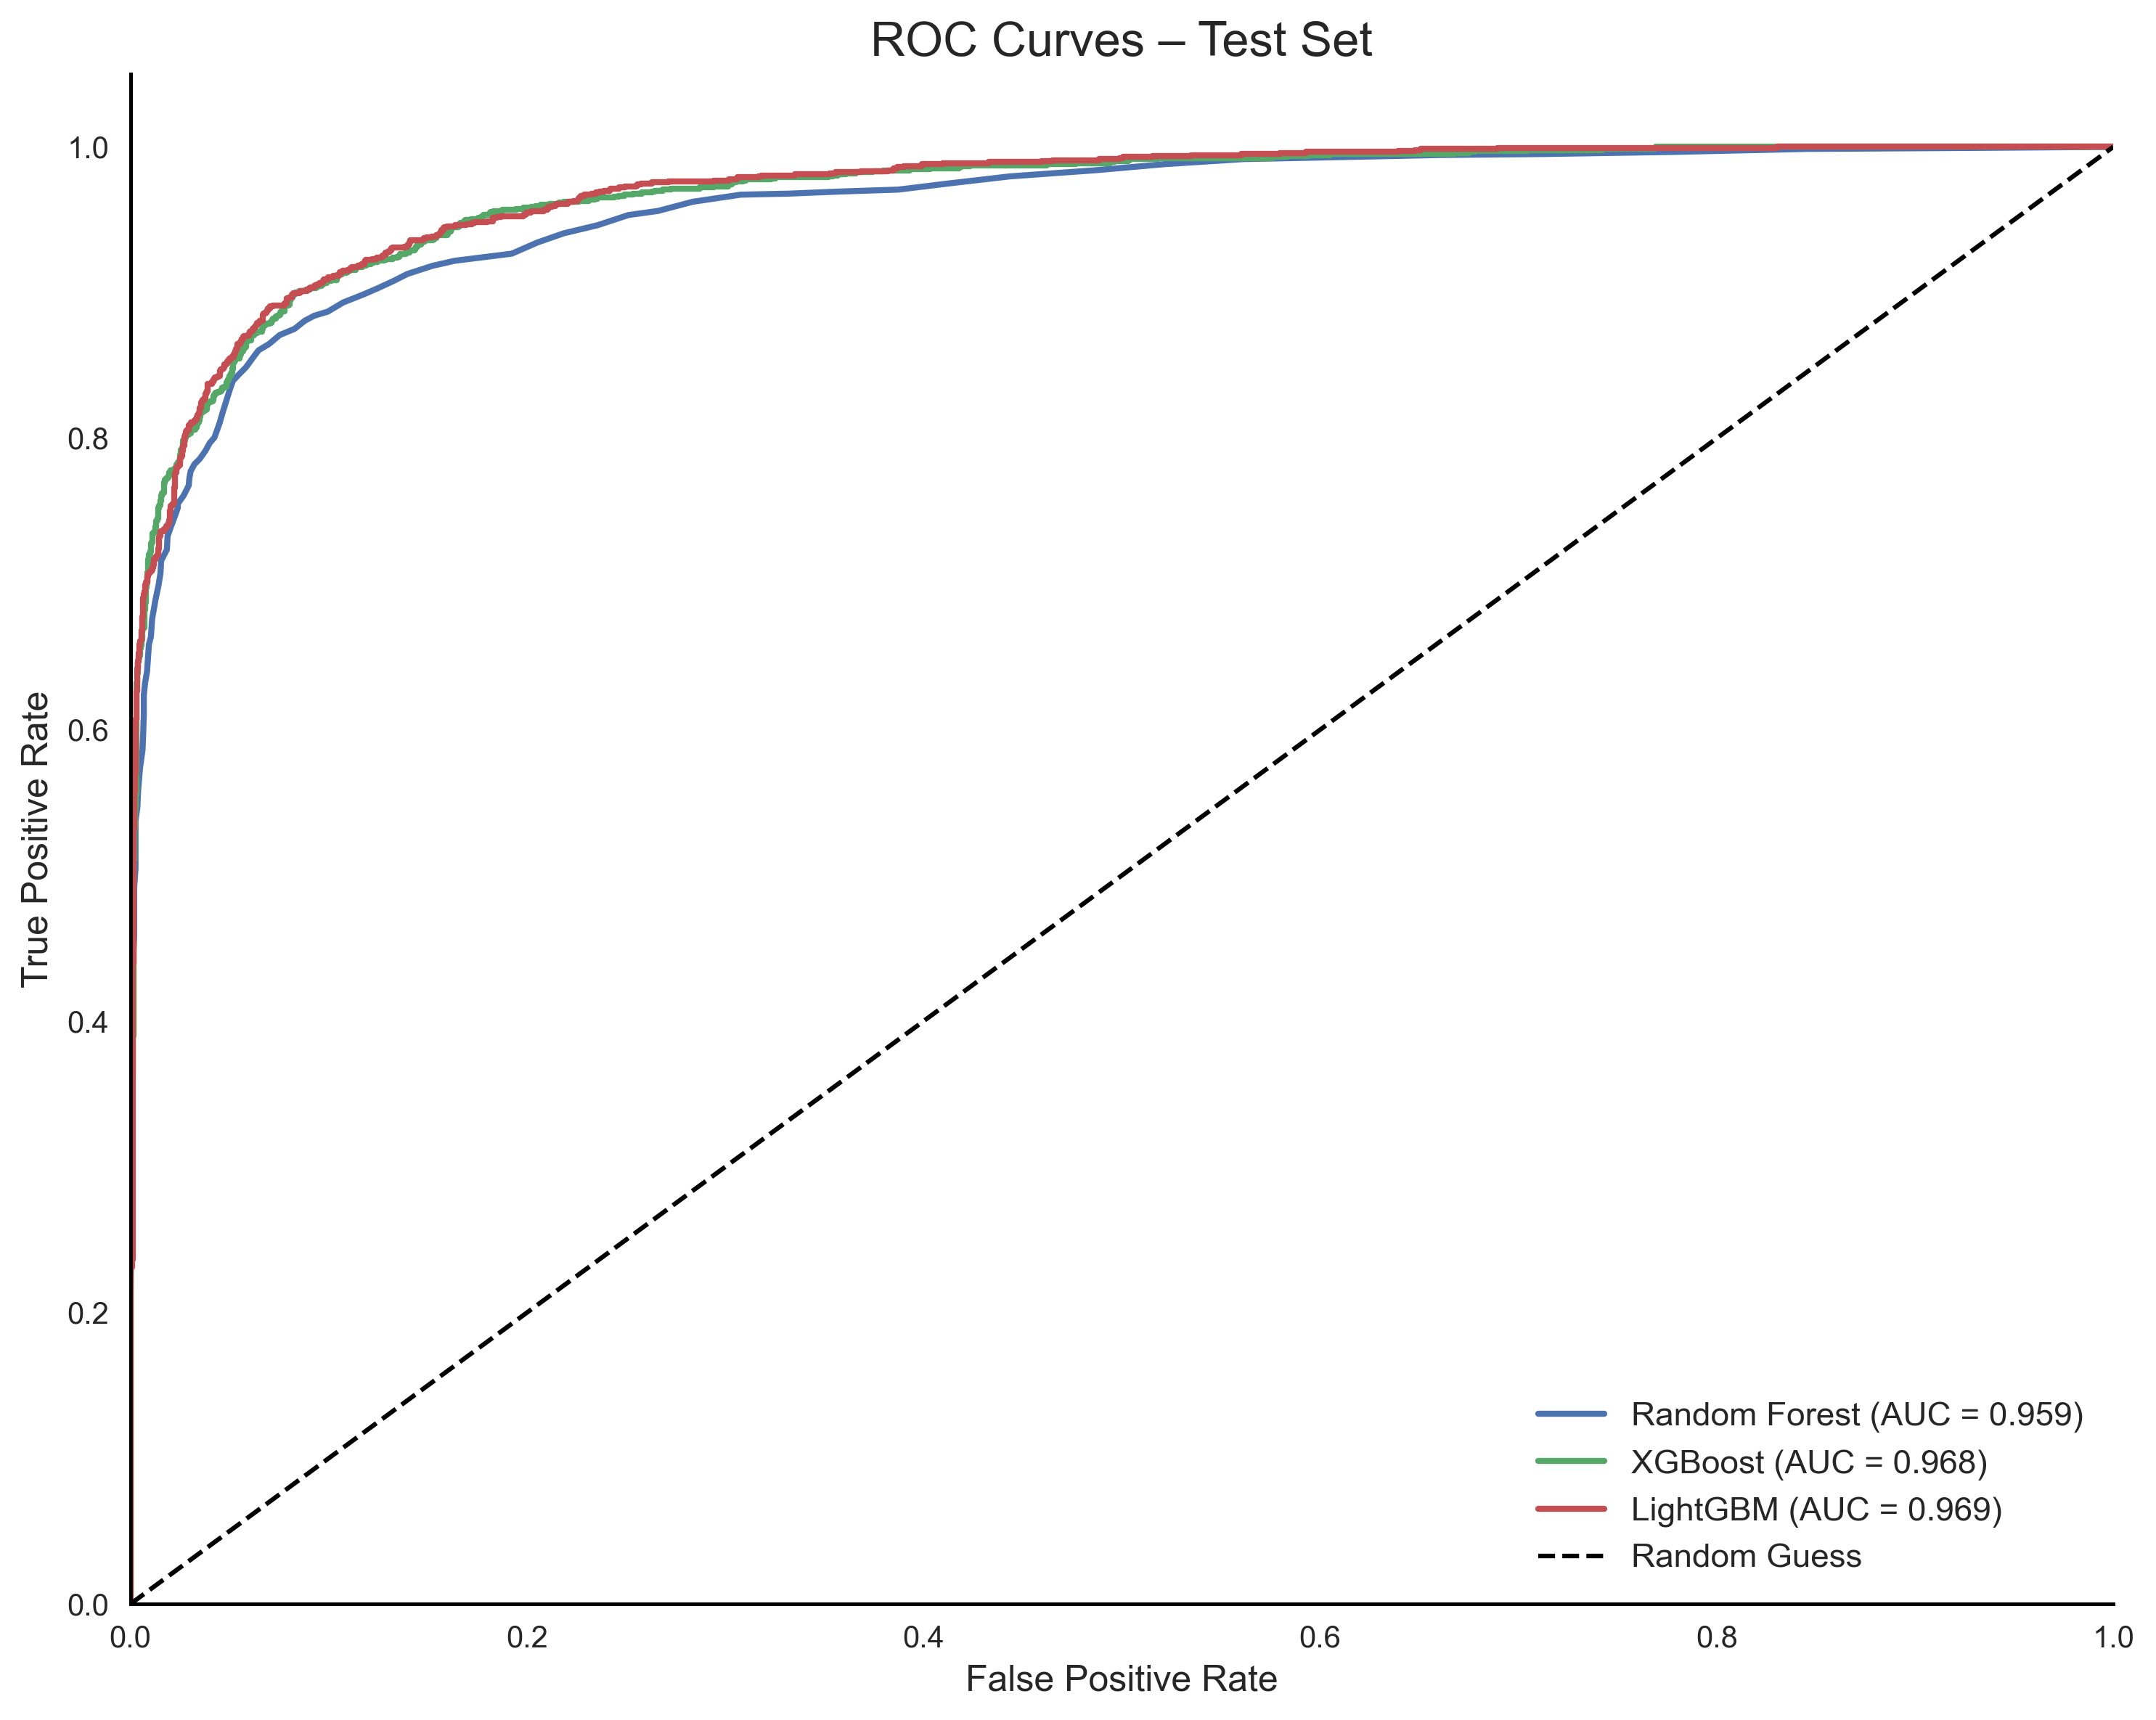

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

ax.set_facecolor("white")
fig.patch.set_facecolor("white")

for name, proba in y_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc_val:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="black", lw=1.5, label="Random Guess")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves – Test Set", fontsize=16)

ax.grid(False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(1.2)
    ax.spines[spine].set_color("black")

ax.legend(loc="lower right", fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig("roc_curves.pdf", bbox_inches="tight")
plt.show()


In [9]:
import joblib
import os

save_dir = "trained_models"
os.makedirs(save_dir, exist_ok=True)

for name, model in trained_models.items():
    filename = f"{save_dir}/{name.replace(' ', '_')}.pkl"
    joblib.dump(model, filename)
    print(f"Saved {name} → {filename}")
    
    print("Models saved")
print("\nFile list:")
for name in trained_models:
    filename = f"{save_dir}/{name.replace(' ', '_')}.pkl"
    size_mb = os.path.getsize(filename) / (1024 * 1024)
    print(f"  • {filename} ({size_mb:.2f} MB)")

Saved Random Forest → trained_models/Random_Forest.pkl
Models saved
Saved XGBoost → trained_models/XGBoost.pkl
Models saved
Saved LightGBM → trained_models/LightGBM.pkl
Models saved

File list:
  • trained_models/Random_Forest.pkl (17.50 MB)
  • trained_models/XGBoost.pkl (0.39 MB)
  • trained_models/LightGBM.pkl (0.35 MB)


In [10]:
df_cv_analysis = cv_df.copy()
df_cv_analysis['roc_auc_CV'] = df_cv_analysis['roc_auc'].apply(lambda x: float(x.split(' ± ')[0]))

df_test_analysis = test_df.copy().reset_index()  # This brings 'Model' back as a column
df_test_analysis = df_test_analysis[['Model', 'roc_auc']].rename(columns={'roc_auc': 'roc_auc_Test'})

comparison = pd.merge(
    df_cv_analysis[['roc_auc_CV']].reset_index(),  # Also reset index here for clean merge
    df_test_analysis,
    on='Model'
)

comparison['Gap'] = comparison['roc_auc_CV'] - comparison['roc_auc_Test']

def diagnose(row):
    gap_threshold = 0.03      # >3% drop suggests overfitting
    score_threshold = 0.70    # CV AUC < 0.70 suggests underfitting
    
    if row['Gap'] > gap_threshold:
        return "Overfitting"
    elif row['roc_auc_CV'] < score_threshold:
        return "Underfitting"
    else:
        return "Good Fit"

comparison['Diagnosis'] = comparison.apply(diagnose, axis=1)

comparison = comparison[['Model', 'roc_auc_CV', 'roc_auc_Test', 'Gap', 'Diagnosis']]
print(comparison.to_string(index=False))

        Model  roc_auc_CV  roc_auc_Test     Gap Diagnosis
Random Forest      0.9524        0.9586 -0.0062  Good Fit
      XGBoost      0.9626        0.9677 -0.0051  Good Fit
     LightGBM      0.9625        0.9690 -0.0065  Good Fit
